In [90]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv('OnlineRetail.csv', encoding='ISO-8859-1')
df.head()



,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [91]:
print(f'количество уникальных заказов: {df["InvoiceNo"].nunique()}')
print(f'количество уникальных товаров: {df["StockCode"].nunique()}')
print(f'размер датафрейма: {df.shape}')
print(f'количество уникальных клиентов: {df["CustomerID"].nunique()}')

количество уникальных заказов: 25900
количество уникальных товаров: 4070
размер датафрейма: (541909, 8)
количество уникальных клиентов: 4372


In [92]:
print(f'пропущенных значений в столбце CustomerID: {df["CustomerID"].isna().sum()}')
print(f'пропущенных значений в столбце InvoiceNo: {df["InvoiceNo"].isna().sum()}')
print(f'пропущенных значений в столбце UnitPrice: {df["UnitPrice"].isna().sum()}')

пропущенных значений в столбце CustomerID: 135080
пропущенных значений в столбце InvoiceNo: 0
пропущенных значений в столбце UnitPrice: 0


In [93]:
df_customers = df.dropna(subset=['CustomerID']).copy()

In [94]:
df_customers['CustomerID'] = df_customers['CustomerID'].astype(int)
df_customers['InvoiceDate'] = pd.to_datetime(df_customers['InvoiceDate'])

print(f'строк для анализа клиентов: {df_customers.shape[0]}')
print(f'уникальных клиентов: {df_customers["CustomerID"].nunique()}')

строк для анализа клиентов: 406829
уникальных клиентов: 4372


In [95]:
df_customers['Revenue'] = df_customers['Quantity'] * df_customers['UnitPrice']
df_customers.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [96]:
df_sales = df_customers[df_customers['Description'].str.isupper() == True]
df_sales['Revenue'] = df_sales['Quantity'] * df_sales['UnitPrice']
df_sales[df_sales['Quantity'] < 0].groupby('Description')['Quantity'].sum().abs().sort_values(ascending=False).head(5)

Description
PAPER CRAFT , LITTLE BIRDIE            80995
MEDIUM CERAMIC TOP STORAGE JAR         74494
ROTATING SILVER ANGELS T-LIGHT HLDR     9367
FAIRY CAKE FLANNEL ASSORTED COLOUR      3150
PINK BLUE FELT CRAFT TRINKET BOX        2617
Name: Quantity, dtype: int64

In [97]:
df_sales.sort_values('Revenue', ascending=True).head()[['Description', 'Revenue']]

,Description,Revenue
540422,"PAPER CRAFT , LITTLE BIRDIE",-168469.60
61624,MEDIUM CERAMIC TOP STORAGE JAR,-77183.60
173277,POSTAGE,-8142.75
160145,FAIRY CAKE FLANNEL ASSORTED COLOUR,-6539.40
160143,WHITE HANGING HEART T-LIGHT HOLDER,-4921.50


In [98]:
df_sales.sort_values('Revenue', ascending=False).head()[['Description', 'Revenue']]

,Description,Revenue
540421,"PAPER CRAFT , LITTLE BIRDIE",168469.60
61619,MEDIUM CERAMIC TOP STORAGE JAR,77183.60
222680,PICNIC BASKET WICKER 60 PIECES,38970.00
173382,POSTAGE,8142.75
348325,SET OF TEA COFFEE SUGAR TINS PANTRY,7144.72


In [99]:
df_sales.groupby('Description')['UnitPrice'].mean().head()

Description
4 PURPLE FLOCK DINNER CANDLES    2.324359
50'S CHRISTMAS GIFT BAG LARGE    1.248091
DOLLY GIRL BEAKER                1.243929
I LOVE LONDON MINI BACKPACK      4.138571
I LOVE LONDON MINI RUCKSACK      4.150000
Name: UnitPrice, dtype: float64

In [100]:
df_sales['Description'] = df_sales['Description'].str.strip()
prices = df_sales[df_sales['Description'] == '4 PURPLE FLOCK DINNER CANDLES']['UnitPrice'].unique()
print(f'уникальные цены на 4 PURPLE FLOCK DINNER CANDLES: {prices}')

уникальные цены на 4 PURPLE FLOCK DINNER CANDLES: [2.55 0.79]


<Axes: title={'center': 'Топ-10 товаров по выручке'}, xlabel='Выручка', ylabel='Товар'>

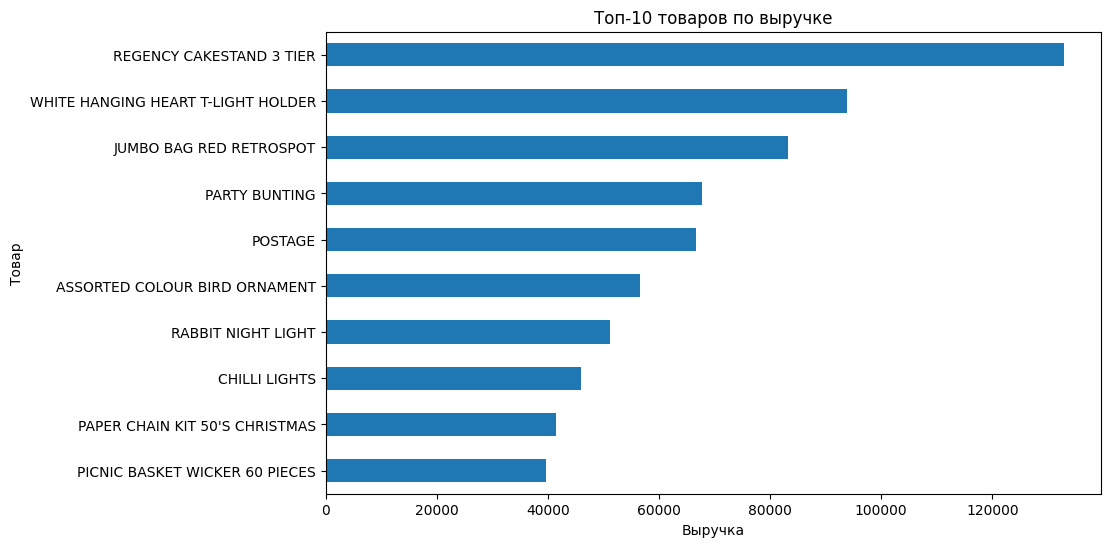

In [101]:
df_sales.groupby('Description')['Revenue'].sum().sort_values(ascending=True)[-10:].plot(kind='barh', figsize=(10, 6), 
                                                                                        title='Топ-10 товаров по выручке', 
                                                                                        xlabel='Выручка', ylabel='Товар')



Country
United Kingdom    360102
Germany             9468
France              8461
EIRE                7455
Spain               2523
Netherlands         2369
Belgium             2060
Switzerland         1874
Portugal            1466
Australia           1259
Name: count, dtype: int64

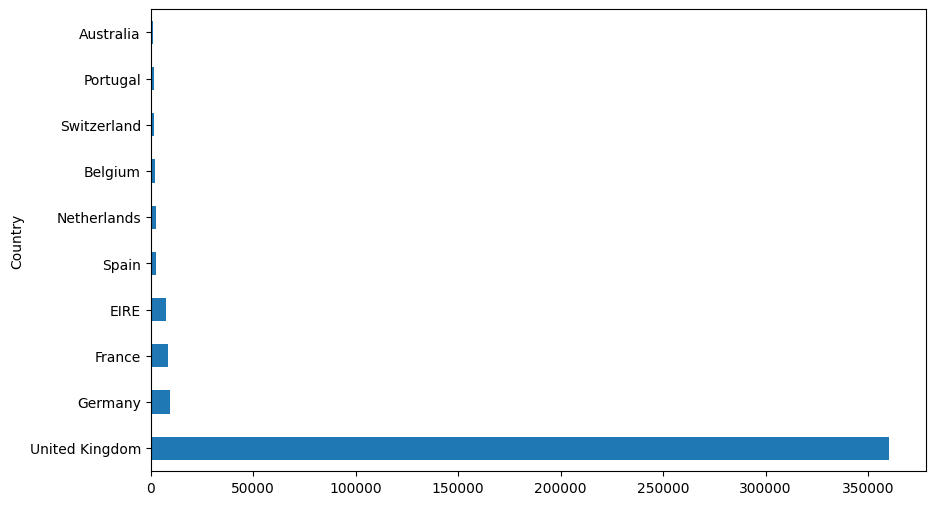

In [102]:
df_sales['Country'].value_counts().head(10).plot(kind='barh', figsize=(10, 6))
df_sales['Country'].value_counts().head(10)

18.93562919117361
Country
Netherlands    120.292756
Australia      108.877895
Japan           99.774056
Sweden          79.543472
Denmark         48.306546
Lithuania       47.458857
Singapore       42.524439
Lebanon         37.641778
Brazil          35.737500
EIRE            33.739264
Name: Revenue, dtype: float64


<Axes: title={'center': 'Средняя выручка по странам'}, xlabel='Средняя выручка', ylabel='Страна'>

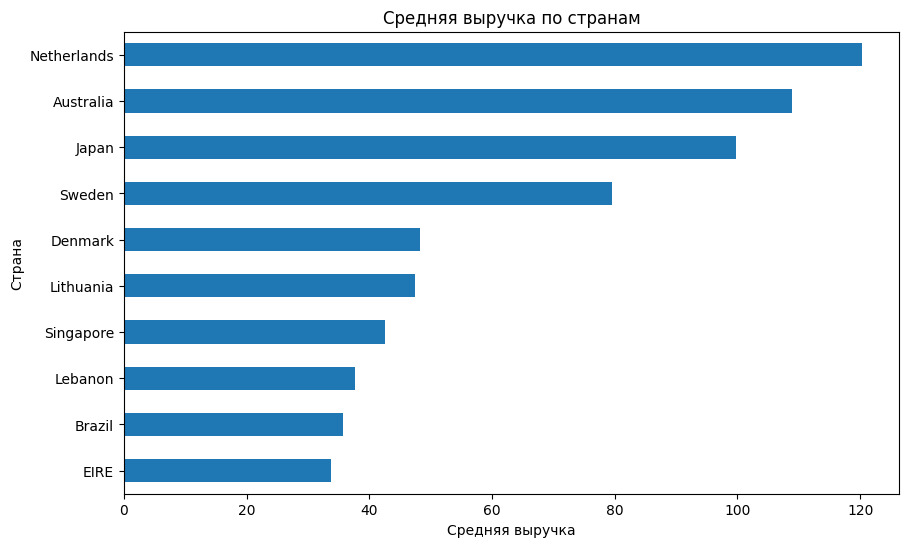

In [103]:
country_revenue = df_sales.groupby('Country')['Revenue'].mean().sort_values(ascending=False).head(10)


print(df_sales[df_sales['Country'] == 'United Kingdom']['Revenue'].mean())
print(country_revenue)

country_revenue.sort_values(ascending=True).plot(kind='barh', figsize=(10, 6), title='Средняя выручка по странам', xlabel='Средняя выручка', ylabel='Страна')

InvoiceMonth
2010-12     554181.120
2011-01     477355.290
2011-02     437302.120
2011-03     579589.520
2011-04     424075.311
2011-05     655676.830
2011-06     645910.910
2011-07     585269.781
2011-08     618073.750
2011-09     929991.761
2011-10     972095.900
2011-11    1131742.360
2011-12     342722.530
Freq: M, Name: Revenue, dtype: float64


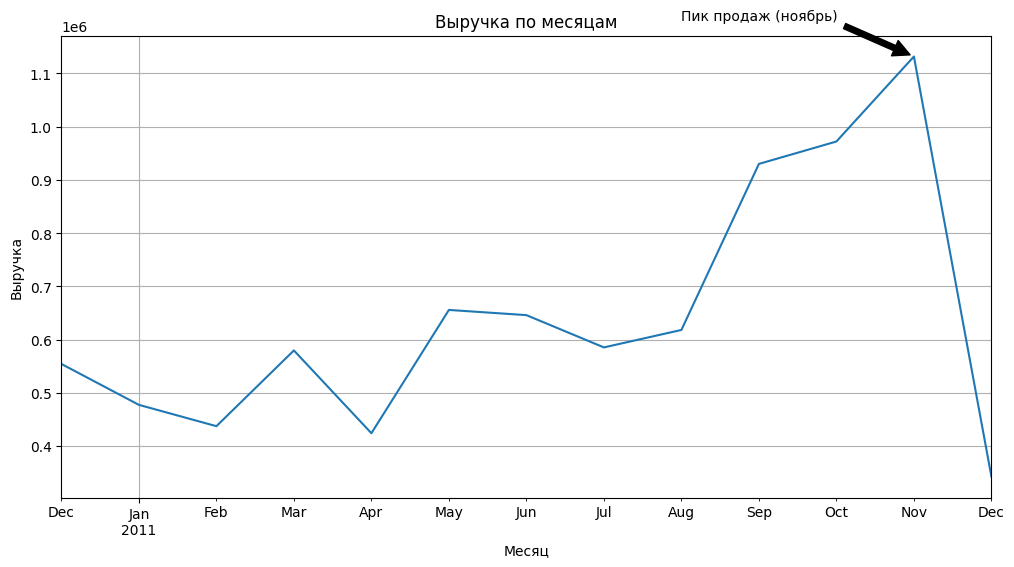

In [104]:
df_sales['InvoiceMonth'] = df_sales['InvoiceDate'].dt.to_period('M')
monthly_revenue = df_sales.groupby('InvoiceMonth')['Revenue'].sum()
print(monthly_revenue)

plt.figure(figsize=(12, 6))
monthly_revenue.plot(kind='line', title='Выручка по месяцам', xlabel='Месяц', ylabel='Выручка')
plt.grid(True)
plt.annotate('Пик продаж (ноябрь)', 
             xy=(pd.Period('2011-11', freq='M'), 1131742), 
             xytext=(pd.Period('2011-08', freq='M'), 1200000),
             arrowprops=dict(facecolor='black', shrink=0.05))
plt.show()




In [105]:
customer_revenue = df_sales.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False).head(10)
total_revenue = df_sales['Revenue'].sum()
customer_revenue_percentage = (customer_revenue / total_revenue) * 100
customer_revenue_percentage = customer_revenue_percentage.head(10)

print(f'Топ-10 клиентов по выручке:\n{customer_revenue}')
print(f'\nОбщая выручка: {total_revenue:.2f}')
print(f'\nДоля выручки от топ-10 клиентов: {customer_revenue_percentage.sum():.2f}%')


Топ-10 клиентов по выручке:
CustomerID
14646    279801.02
18102    259657.30
17450    188745.05
14911    132779.63
12415    123725.45
14156    114418.12
17511     88014.31
16684     65920.12
14096     65046.40
13694     62835.79
Name: Revenue, dtype: float64

Общая выручка: 8353987.18

Доля выручки от топ-10 клиентов: 16.53%


Топ-10 товаров по выручке:

Description
REGENCY CAKESTAND 3 TIER              132870.40
WHITE HANGING HEART T-LIGHT HOLDER     93823.85
JUMBO BAG RED RETROSPOT                83236.76
PARTY BUNTING                          67687.53
POSTAGE                                66710.24
ASSORTED COLOUR BIRD ORNAMENT          56499.22
RABBIT NIGHT LIGHT                     51137.80
CHILLI LIGHTS                          45936.81
PAPER CHAIN KIT 50'S CHRISTMAS         41500.48
PICNIC BASKET WICKER 60 PIECES         39619.50
Name: Revenue, dtype: float64


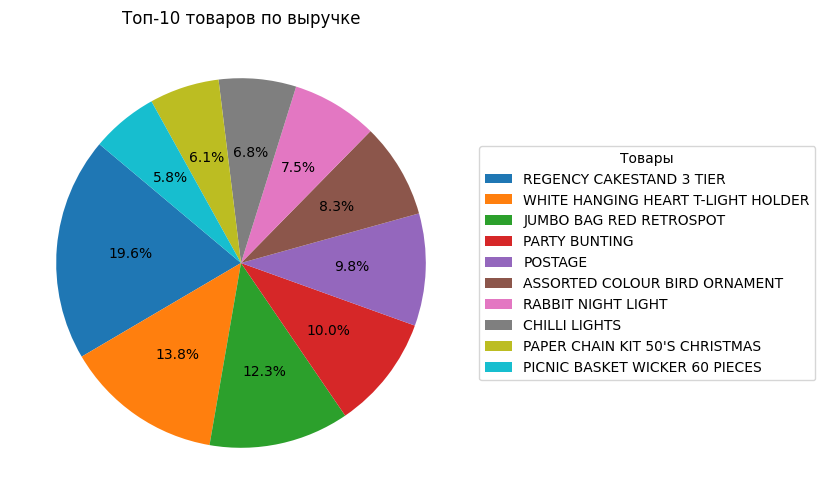

In [106]:
item_revenue = df_sales.groupby('Description')['Revenue'].sum().sort_values(ascending=False)
top_10_items = item_revenue.head(10)
print(f'Топ-10 товаров по выручке:\n\n{top_10_items}')


plt.figure(figsize=(12, 6))
plt.pie(top_10_items, autopct='%1.1f%%', startangle=140)
plt.legend(top_10_items.index, title='Товары', loc='center left', bbox_to_anchor=(1, 0, 0.5, 1))
plt.title('Топ-10 товаров по выручке')
plt.show()

In [107]:
negative_revenue_items = item_revenue[item_revenue < 0].sort_values()
print(f'Товары с отрицательной выручкой:\n{negative_revenue_items.head(10)}')

Товары с отрицательной выручкой:
Description
CHALKBOARD KITCHEN ORGANISER      -87.80
WHITE CHERRY LIGHTS               -54.00
CREAM SWEETHEART MAGAZINE RACK    -46.85
WOODEN BOX ADVENT CALENDAR        -45.70
ASSORTED TUTTI FRUTTI ROUND BOX   -39.60
PINK CHERRY LIGHTS                -27.00
BLUE PADDED SOFT MOBILE           -25.50
ANTIQUE LILY FAIRY LIGHTS         -14.85
CREAM SWEETHEART TRAYS            -12.75
TEA TIME CAKE STAND IN GIFT BOX   -10.75
Name: Revenue, dtype: float64
